**Analisis Sentimen terhadap aplikasi My Telkomsel menggunakan metode Naive Bayes**

**1. PENGAMBILAMN DATA**

Pengambilan Dataset Tahap 1

Instalasi Library

In [1]:
pip install google-play-scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.1 MB/s eta 0:00:00


Import Library

In [2]:
from google_play_scraper import Sort, reviews
from google_play_scraper import app
import pandas as pd
import numpy as np

Proses Scrape Ulasan Aplikasi

In [3]:
result, continuation_token = reviews(
    'com.telkomsel.telkomselcm',
    lang='id', #bahasa
    country='id', #negara
    sort=Sort.MOST_RELEVANT, #sorting yg paling relevan
    count=2000, #jumlah dataset
    filter_score_with= None
)

Pengambilan Dataset Tahap 2

Konversi data ke DataFrame (Struktur Tabel)

In [4]:
df_data = pd.DataFrame(np.array(result), columns=['review'])
df_data = df_data.join(pd.DataFrame(df_data.pop('review').tolist()))
df_data.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,130bc885-d7e6-4d40-ad91-a4f5d5a53c45,Doni Radhianto,https://play-lh.googleusercontent.com/a-/ALV-U...,"Aplikasi SERAKAH, semua dimasukin, tidak setab...",1,8,9.2.1,2026-06-08 09:08:40,Maaf banget Kak Doni. Perihal aplikasi MyTelko...,2026-05-30 16:43:19,9.2.1
1,6dbf2638-f37c-4ec9-ac8c-8e9aab289086,dhafiya alima,https://play-lh.googleusercontent.com/a/ACg8oc...,"Beli paket data aja gak bisa bisa dari tadi, l...",1,7,9.2.1,2026-05-30 05:57:53,Hai Kak Dhafiya. Mohon maaf untuk ketidaknyama...,2026-05-30 07:51:07,9.2.1
2,2e2ed06d-05a5-43e5-943a-3bc81cb8cf3f,M.Sukron Siregar,https://play-lh.googleusercontent.com/a-/ALV-U...,Ada banyak sekali errornya. Mulai dari aplikas...,1,2,9.2.1,2026-06-08 23:55:13,"Hai Kak Sukron, mohon maaf ya kak jika aplikas...",2026-06-09 04:09:28,9.2.1
3,3e679be8-86e6-4a7b-9c02-d01399a139a2,Muhammad Sakhi,https://play-lh.googleusercontent.com/a-/ALV-U...,reting buat telkomsel -5 bintang. Jaringan mak...,1,24,9.2.0,2026-05-01 06:47:49,Hai Kak Sakhi. Maaf banget ya. Silakan akses a...,2026-05-01 11:32:06,9.2.0
4,5e5e9570-45bd-4d4c-8a67-afb6a4aa5936,Ajeng Sinta,https://play-lh.googleusercontent.com/a/ACg8oc...,"satu jam ada keknya mau beli kuota, lama bange...",1,14,9.2.0,2026-05-16 02:43:22,Hai Kak Ajeng. Mohon maaf untuk ketidaknyamana...,2026-05-16 06:55:26,9.2.0


Perhitungan dan penyortiran data

In [5]:
df_data.to_csv('ulasan_mytelkomsel_scrapping.csv', index = False) #mengunduh file csvnya

In [6]:
len(df_data)

2000

In [7]:
df_data[['userName', 'score', 'at', 'content']].head()

,userName,score,at,content
0,Doni Radhianto,1,2026-06-08 09:08:40,"Aplikasi SERAKAH, semua dimasukin, tidak setab..."
1,dhafiya alima,1,2026-05-30 05:57:53,"Beli paket data aja gak bisa bisa dari tadi, l..."
2,M.Sukron Siregar,1,2026-06-08 23:55:13,Ada banyak sekali errornya. Mulai dari aplikas...
3,Muhammad Sakhi,1,2026-05-01 06:47:49,reting buat telkomsel -5 bintang. Jaringan mak...
4,Ajeng Sinta,1,2026-05-16 02:43:22,"satu jam ada keknya mau beli kuota, lama bange..."


In [8]:
df_data = df_data[['content','score']] #karena kita hanya membutuhkan kolom content dan score maka kita lakukan filter kolom lgi hingga menyisakan kolom

In [9]:
df_data.head()

,content,score
0,"Aplikasi SERAKAH, semua dimasukin, tidak setab...",1
1,"Beli paket data aja gak bisa bisa dari tadi, l...",1
2,Ada banyak sekali errornya. Mulai dari aplikas...,1
3,reting buat telkomsel -5 bintang. Jaringan mak...,1
4,"satu jam ada keknya mau beli kuota, lama bange...",1


In [10]:
df_data = df_data.rename (columns={'content': 'ulasan', 'score': 'value'})
df_data.head()

,ulasan,value
0,"Aplikasi SERAKAH, semua dimasukin, tidak setab...",1
1,"Beli paket data aja gak bisa bisa dari tadi, l...",1
2,Ada banyak sekali errornya. Mulai dari aplikas...,1
3,reting buat telkomsel -5 bintang. Jaringan mak...,1
4,"satu jam ada keknya mau beli kuota, lama bange...",1


**PELABELAN DATA**

In [11]:
def pelabelan(value):
  if value < 3:
    return 'Negatif'
  elif value == 4:
    return 'Positif'
  elif value == 5:
    return 'Positif'
df_data['Label'] = df_data['value'].apply(pelabelan)
df_data.head(200)

,ulasan,value,Label
0,"Aplikasi SERAKAH, semua dimasukin, tidak setab...",1,Negatif
1,"Beli paket data aja gak bisa bisa dari tadi, l...",1,Negatif
2,Ada banyak sekali errornya. Mulai dari aplikas...,1,Negatif
3,reting buat telkomsel -5 bintang. Jaringan mak...,1,Negatif
4,"satu jam ada keknya mau beli kuota, lama bange...",1,Negatif
...,...,...,...
195,"gak bagus banget mending pake provider lain, a...",1,Negatif
196,ini kenapa harga makin lama makin mahal tapi k...,1,Negatif
197,banyak kendalanya. sering gangguan sinyal jari...,1,Negatif
198,telkomsel tolong buat fitur tukar poin ke kuot...,4,Positif


**PREPROCESSING DATA**

Kode Handling Missing Value - Ignore Tuple

In [12]:
# Mencari jumlah baris data yang bernilai null
# terdapat kolom label memiliki nilai kosong
df_data.isnull().sum()

,0
ulasan,0
value,0
Label,146


In [13]:
# Handling Missing value-Ignore tuple
df_data.dropna(subset=['Label'], inplace=True)


In [14]:
df_data.isnull().sum()

,0
ulasan,0
value,0
Label,0


In [15]:
df_data.head(200)

,ulasan,value,Label
0,"Aplikasi SERAKAH, semua dimasukin, tidak setab...",1,Negatif
1,"Beli paket data aja gak bisa bisa dari tadi, l...",1,Negatif
2,Ada banyak sekali errornya. Mulai dari aplikas...,1,Negatif
3,reting buat telkomsel -5 bintang. Jaringan mak...,1,Negatif
4,"satu jam ada keknya mau beli kuota, lama bange...",1,Negatif
...,...,...,...
212,"mytelkomel aplikasi bobrok, buka aplikasi lain...",1,Negatif
213,"aplikasi rusak. jaringan saya bagus , update s...",1,Negatif
214,pemberitahuan kuota habis atau sisa dikit seri...,1,Negatif
215,pemeras saldo masyarakat... tiap abis beli pak...,1,Negatif


In [16]:
df_data_value_3 = df_data[df_data['value'] == 3]
display(df_data_value_3)

,ulasan,value,Label


Cleaning Data

In [17]:
import re

def clean_text(df, content_field_name, new_text_field_name):
    df[new_text_field_name] = df[content_field_name].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', str(x).lower())) # remove special characters and convert to lowercase
    # remove numbers
    df[new_text_field_name] = df[new_text_field_name].apply(lambda x: re.sub(r'\d+', '', x))
    return df

df_data['text_clean'] = df_data['ulasan']
data_clean = clean_text(df_data, 'ulasan', 'text_clean')
data_clean.head(100)

,ulasan,value,Label,text_clean
0,"Aplikasi SERAKAH, semua dimasukin, tidak setab...",1,Negatif,aplikasi serakah semua dimasukin tidak setabil...
1,"Beli paket data aja gak bisa bisa dari tadi, l...",1,Negatif,beli paket data aja gak bisa bisa dari tadi lo...
2,Ada banyak sekali errornya. Mulai dari aplikas...,1,Negatif,ada banyak sekali errornya mulai dari aplikasi...
3,reting buat telkomsel -5 bintang. Jaringan mak...,1,Negatif,reting buat telkomsel bintang jaringan makin ...
4,"satu jam ada keknya mau beli kuota, lama bange...",1,Negatif,satu jam ada keknya mau beli kuota lama banget...
...,...,...,...,...
100,opsi tukar pointnya tidak berguna... ini provi...,1,Negatif,opsi tukar pointnya tidak berguna ini provider...
101,"kualitas jaringan makin menurun,,, padahal tin...",1,Negatif,kualitas jaringan makin menurun padahal tingga...
102,"performa aplikasi naik sedikit, yang buruk skr...",2,Negatif,performa aplikasi naik sedikit yang buruk skrg...
104,"aplikasi ini ada aneh anehnya, pas udah lama s...",1,Negatif,aplikasi ini ada aneh anehnya pas udah lama si...


Case Folding

In [18]:
import re

def clean_text(df, text_field, new_text_field_name):
    df[new_text_field_name] = df[text_field].apply(lambda elem: re.sub(r"(@[A-Za-z0-9]+)|([^0-9A-Za-z \t])|(\w+:\/\/\S+)|^rt|http.+?", " ", str(elem).lower()))
    # remove numbers
    df[new_text_field_name] = df[new_text_field_name].apply(lambda elem: re.sub(r"\d+", "", elem))
    return df

df_data['text_clean'] = df_data['ulasan']
data_clean = clean_text(df_data, 'ulasan', 'text_clean')
data_clean.head(20)

,ulasan,value,Label,text_clean
0,"Aplikasi SERAKAH, semua dimasukin, tidak setab...",1,Negatif,aplikasi serakah semua dimasukin tidak setab...
1,"Beli paket data aja gak bisa bisa dari tadi, l...",1,Negatif,beli paket data aja gak bisa bisa dari tadi l...
2,Ada banyak sekali errornya. Mulai dari aplikas...,1,Negatif,ada banyak sekali errornya mulai dari aplikas...
3,reting buat telkomsel -5 bintang. Jaringan mak...,1,Negatif,reting buat telkomsel bintang jaringan maki...
4,"satu jam ada keknya mau beli kuota, lama bange...",1,Negatif,satu jam ada keknya mau beli kuota lama bange...
5,"Parah banget, setelah update malah nggak bisa ...",1,Negatif,parah banget setelah update malah nggak bisa ...
6,youtbe premium nya kenapa tidak bisa di aktiva...,1,Negatif,youtbe premium nya kenapa tidak bisa di aktiva...
8,"bagus, tp: 1. kadang suka ngebug... harap dipe...",1,Negatif,bagus tp kadang suka ngebug harap diper...
9,"paket internet kian mahal, pengguna lama tidak...",1,Negatif,paket internet kian mahal pengguna lama tidak...
10,developer tidak niat. Login pakai nomor hp saj...,1,Negatif,developer tidak niat login pakai nomor hp saj...


In [19]:
display(data_clean.iloc[[7, 13]])

,ulasan,value,Label,text_clean
8,"bagus, tp: 1. kadang suka ngebug... harap dipe...",1,Negatif,bagus tp kadang suka ngebug harap diper...
15,tolong aplikasi itu di buat lebih manfaat saja...,2,Negatif,tolong aplikasi itu di buat lebih manfaat saja...


Stopword Removal

In [ ]:
import nltk.corpus
nltk.download('stopwords')
from nltk.corpus import stopwords

stop = stopwords.words('indonesian')

my_stopwords = (['ada', 'adalah', 'agar', 'aja', 'akan', 'aku', 'apa', 'apakah', 'atau', 'bagaimana', 'banyak', 'bapak', 'baru', 'beberapa', 'begitu', 'belum', 'berarti',
                 'berat', 'berikan', 'beserta', 'biasa', 'biasanya', 'bikin', 'bila', 'bisa', 'buat', 'buka', 'bukan', 'bung', 'dan', 'dapat', 'dari', 'daripada', 'deh', 'demi', 'dengan',
                 'depannya', 'di', 'dia', 'diadakan', 'dialah', 'diantaranya', 'diberikan', 'dibuat', 'didapat', 'digunakan', 'diingatkan', 'dirinya', 'dong', 'dulu', 'enggak', 'engkau', 'ga',
                 'gak', 'gimana', 'gini', 'gitu', 'gk', 'guna', 'gue', 'habis', 'hadapan', 'harus', 'harusnya', 'hendak', 'pula', 'pun', 'sama', 'sampai', 'samping', 'sana', 'sangat', 'sarana',
                 'saya', 'sebab', 'sebelum', 'sebagainya', 'secara', 'sedang', 'sedikit', 'segera', 'sehingga', 'sekali', 'sekalian', 'sekarang', 'selaku', 'selalu', 'sementara', 'semua', 'sendiri',
                 'sentosa', 'sering', 'serta', 'setiap', 'si', 'sih', 'siapa', 'sini', 'sinyal', 'situ', 'supaya', 'sudah', 'tadi', 'tapi', 'telah', 'telkomsel', 'tempat', 'tengah', 'tentang',
                 'tentu', 'terus', 'tiap', 'tidak', 'trs', 'untuk', 'walau', 'walaupun', 'waktu', 'yah', 'yaitu', 'yang', 'yg', 'cuih'])

stop.extend(my_stopwords)
data_clean['text_Stopword'] = data_clean['text_clean'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop)]))
data_clean.head(5)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,ulasan,value,Label,text_clean,text_Stopword,text_tokens,text_stemindo
0,"Aplikasi SERAKAH, semua dimasukin, tidak setab...",1,Negatif,aplikasi serakah semua dimasukin tidak setab...,aplikasi serakah dimasukin setabil jarak bts s...,"[aplikasi, serakah, dimasukin, setabil, jarak,...",aplikasi serakah dimasukin setabil jarak bts r...
1,"Beli paket data aja gak bisa bisa dari tadi, l...",1,Negatif,beli paket data aja gak bisa bisa dari tadi l...,beli paket data loading nya bangetttttttt ting...,"[beli, paket, data, loading, nya, bangettttttt...",beli paket data loading nya bangetttttttt ting...
2,Ada banyak sekali errornya. Mulai dari aplikas...,1,Negatif,ada banyak sekali errornya mulai dari aplikas...,errornya aplikasi lelet jaringan bagus aplikas...,"[errornya, aplikasi, yg, lelet, jaringan, apli...",errornya aplikasi yg lelet jaring aplikasi lan...
3,reting buat telkomsel -5 bintang. Jaringan mak...,1,Negatif,reting buat telkomsel bintang jaringan maki...,reting bintang jaringan buruk harga paket maha...,"[reting, bintang, jaringan, buruk, harga, pake...",reting bintang jaring buruk harga paket mahal ...
4,"satu jam ada keknya mau beli kuota, lama bange...",1,Negatif,satu jam ada keknya mau beli kuota lama bange...,jam keknya beli kuota banget udah force close ...,"[jam, keknya, beli, kuota, udah, force, close,...",jam kek beli kuota udah force close halaman pu...


Tokenizing

In [ ]:
import nltk

data_clean['text_tokens'] = data_clean['text_Stopword'].apply(lambda x: x.split())
data_clean.head(5)

,ulasan,value,Label,text_clean,text_Stopword,text_tokens
0,"Aplikasi SERAKAH, semua dimasukin, tidak setab...",1,Negatif,aplikasi serakah semua dimasukin tidak setab...,aplikasi serakah dimasukin setabil jarak bts s...,"[aplikasi, serakah, dimasukin, setabil, jarak,..."
1,"Beli paket data aja gak bisa bisa dari tadi, l...",1,Negatif,beli paket data aja gak bisa bisa dari tadi l...,beli paket data loading nya bangetttttttt ting...,"[beli, paket, data, loading, nya, bangettttttt..."
2,Ada banyak sekali errornya. Mulai dari aplikas...,1,Negatif,ada banyak sekali errornya mulai dari aplikas...,errornya aplikasi yg lelet jaringan aplikasi l...,"[errornya, aplikasi, yg, lelet, jaringan, apli..."
3,reting buat telkomsel -5 bintang. Jaringan mak...,1,Negatif,reting buat telkomsel bintang jaringan maki...,reting bintang jaringan buruk harga paket maha...,"[reting, bintang, jaringan, buruk, harga, pake..."
4,"satu jam ada keknya mau beli kuota, lama bange...",1,Negatif,satu jam ada keknya mau beli kuota lama bange...,jam keknya beli kuota udah force close halaman...,"[jam, keknya, beli, kuota, udah, force, close,..."


Stemming

In [22]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.1 MB/s eta 0:00:00


In [ ]:
#-------------------STEMMING-----------------
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# create stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# stemmed
def stemmed_wrapper(term):
    # Avoid stemming words that are important for sentiment like 'bagus'
    if term in ['bagus', 'baik', 'oke', 'mantap', 'cepat', 'mudah']: # Add more positive words if needed
        return term
    return stemmer.stem(term)

term_dict = {}
hitung=0

for document in data_clean['text_tokens']:
    for term in document:
        if term not in term_dict:
            term_dict[term] = ''

print(len(term_dict))
print("------------------------")

max_print_terms = 50
printed_count = 0

for term in term_dict:
    term_dict[term] = stemmed_wrapper(term)
    hitung+=1
    if printed_count < max_print_terms:
        print(hitung,":",term,":",term_dict[term])
        printed_count += 1

# print(term_dict) # Avoid printing the entire dictionary if it's very large
print("------------------------")

# apply stemmed term to dataframe
def get_stemmed_term(document):
    return [term_dict[term] for term in document]

#script ini bisa dipisah dari eksekusinya setelah pembacaan term selesai
data_clean['text_stemindo'] = data_clean['text_tokens'].apply(lambda x: ' '.join(get_stemmed_term(x)))
data_clean.head(20)

5147
------------------------
1 : aplikasi : aplikasi
2 : serakah : serakah
3 : dimasukin : dimasukin
4 : setabil : setabil
5 : jarak : jarak
6 : bts : bts
7 : seratus : ratus
8 : meter : meter
9 : tunda : tunda
10 : animasinya : animasi
11 : lambat : lambat
12 : bermasalah : masalah
13 : restart : restart
14 : file : file
15 : cache : cache
16 : kosong : kosong
17 : beli : beli
18 : paket : paket
19 : data : data
20 : loading : loading
21 : nya : nya
22 : bangetttttttt : bangetttttttt
23 : tinggal : tinggal
24 : pembayaran : bayar
25 : doang : doang
26 : stabilin : stabilin
27 : fitur : fitur
28 : lo : lo
29 : heran : heran
30 : pulsa : pulsa
31 : lelet : lelet
32 : bgt : bgt
33 : errornya : errornya
34 : yg : yg
35 : jaringan : jaring
36 : lancar : lancar
37 : menawarkan : tawar
38 : promo : promo
39 : kuota : kuota
40 : murah : murah
41 : dibeli : beli
42 : kendala : kendala
43 : respon : respon
44 : menangani : tangan
45 : kali : kali
46 : bulanan : bulan
47 : m : m
48 : banking : 

,ulasan,value,Label,text_clean,text_Stopword,text_tokens,text_stemindo
0,"Aplikasi SERAKAH, semua dimasukin, tidak setab...",1,Negatif,aplikasi serakah semua dimasukin tidak setab...,aplikasi serakah dimasukin setabil jarak bts s...,"[aplikasi, serakah, dimasukin, setabil, jarak,...",aplikasi serakah dimasukin setabil jarak bts r...
1,"Beli paket data aja gak bisa bisa dari tadi, l...",1,Negatif,beli paket data aja gak bisa bisa dari tadi l...,beli paket data loading nya bangetttttttt ting...,"[beli, paket, data, loading, nya, bangettttttt...",beli paket data loading nya bangetttttttt ting...
2,Ada banyak sekali errornya. Mulai dari aplikas...,1,Negatif,ada banyak sekali errornya mulai dari aplikas...,errornya aplikasi yg lelet jaringan aplikasi l...,"[errornya, aplikasi, yg, lelet, jaringan, apli...",errornya aplikasi yg lelet jaring aplikasi lan...
3,reting buat telkomsel -5 bintang. Jaringan mak...,1,Negatif,reting buat telkomsel bintang jaringan maki...,reting bintang jaringan buruk harga paket maha...,"[reting, bintang, jaringan, buruk, harga, pake...",reting bintang jaring buruk harga paket mahal ...
4,"satu jam ada keknya mau beli kuota, lama bange...",1,Negatif,satu jam ada keknya mau beli kuota lama bange...,jam keknya beli kuota udah force close halaman...,"[jam, keknya, beli, kuota, udah, force, close,...",jam kek beli kuota udah force close halaman pu...
5,"Parah banget, setelah update malah nggak bisa ...",1,Negatif,parah banget setelah update malah nggak bisa ...,parah update nggak login nomor aktif dibilang ...,"[parah, update, nggak, login, nomor, aktif, di...",parah update nggak login nomor aktif bilang re...
6,youtbe premium nya kenapa tidak bisa di aktiva...,1,Negatif,youtbe premium nya kenapa tidak bisa di aktiva...,youtbe premium nya aktivasi terpotong pulsa ke...,"[youtbe, premium, nya, aktivasi, terpotong, pu...",youtbe premium nya aktivasi potong pulsa teran...
8,"bagus, tp: 1. kadang suka ngebug... harap dipe...",1,Negatif,bagus tp kadang suka ngebug harap diper...,tp kadang suka ngebug harap diperbaiki aplikas...,"[tp, kadang, suka, ngebug, harap, diperbaiki, ...",tp kadang suka ngebug harap baik aplikasi load...
9,"paket internet kian mahal, pengguna lama tidak...",1,Negatif,paket internet kian mahal pengguna lama tidak...,paket internet kian mahal pengguna diprioritas...,"[paket, internet, kian, mahal, pengguna, dipri...",paket internet kian mahal guna prioritas guna ...
10,developer tidak niat. Login pakai nomor hp saj...,1,Negatif,developer tidak niat login pakai nomor hp saj...,developer niat login pakai nomor hp otp masuk ...,"[developer, niat, login, pakai, nomor, hp, otp...",developer niat login pakai nomor hp otp masuk ...


**KLASIFIKASI MODEL**

In [24]:
#membagi data menjadi data training dan testing dengan test_size = 0.20 dan random state nya 0
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data_clean['ulasan'], data_clean['Label'],
                                                    test_size = 0.20,
                                                    random_state = 0)

In [ ]:
#Menggunakan len() untuk menghitung jumlah baris
print(len(data_clean))

1854


Pembobotan Data

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()
tfidf_train = tfidf_vectorizer.fit_transform(X_train)
tfidf_test = tfidf_vectorizer.transform(X_test)

In [27]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(1483,)
(1483,)
(371,)
(371,)


In [28]:
from sklearn.feature_extraction.text import CountVectorizer

# Adjust CountVectorizer parameters - e.g., min_df to include less frequent words
# or max_df to exclude very frequent words that might not be informative.
# ngram_range can also be explored to capture phrases.
vectorizer = CountVectorizer(min_df=1, ngram_range=(1, 2)) # Example: include all terms and consider bigrams
X_train_vectorized = vectorizer.fit_transform(X_train)

In [29]:
X_test_vectorized = vectorizer.transform(X_test)

**Klasifikasi Naive Bayes**

In [30]:
from sklearn.naive_bayes import MultinomialNB

# Inisialisasi model Multinomial Naive Bayes
nb = MultinomialNB()

# Melatih model dengan data training
nb.fit(tfidf_train, y_train)

MultinomialNB()

In [ ]:
from sklearn.naive_bayes import MultinomialNB

# Inisialisasi model Multinomial Naive Bayes
nb = MultinomialNB()

# Melatih model dengan data training
nb.fit(tfidf_train, y_train)


MultinomialNB()

In [33]:
# Melakukan prediksi pada data test
y_pred = nb.predict(tfidf_test)

In [34]:
from sklearn.metrics import accuracy_score

# Menghitung akurasi model
accuracy = accuracy_score(y_test, y_pred)

In [35]:
# Menampilkan nilai akurasi
print(accuracy)

0.9245283018867925


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Menampilkan Akurasi
print(f"MultinomialNB Accuracy: {accuracy}")
print("\nconfusion_matrix:")

# Menghitung dan menampilkan Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Menampilkan Classification Report
print("\n" + "="*50) # Garis pemisah
report = classification_report(y_test, y_pred, target_names=['Negatif', 'Positif'])
print(report)

MultinomialNB Accuracy: 0.9245283018867925

confusion_matrix:
[[343   0]
 [ 28   0]]

              precision    recall  f1-score   support

     Negatif       0.92      1.00      0.96       343
     Positif       0.00      0.00      0.00        28

    accuracy                           0.92       371
   macro avg       0.46      0.50      0.48       371
weighted avg       0.85      0.92      0.89       371



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


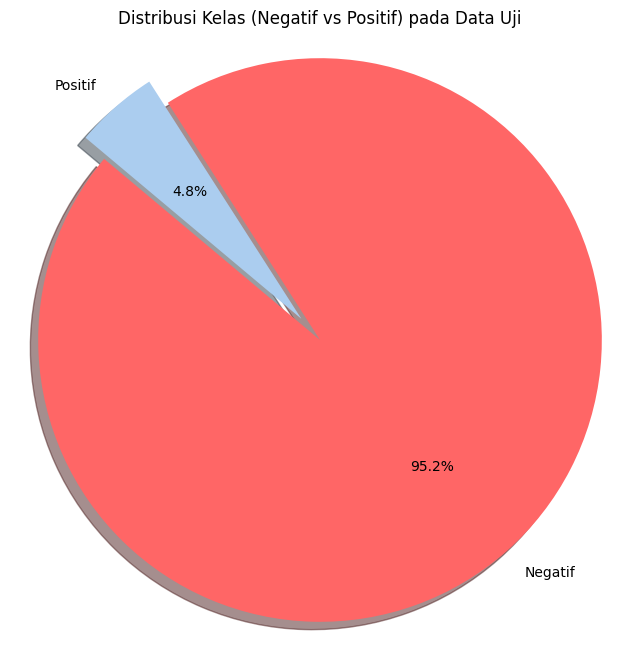

In [ ]:
import matplotlib.pyplot as plt

# Data dari 'support' di classification_report 
labels = ['Negatif', 'Positif']
sizes = [356, 18]
colors = ['#ff6666', '#abcdef'] # Warna untuk setiap bagian
explode = (0.1, 0)  # "Memisahkan" bagian pertama (Negatif)

# Membuat diagram pie
plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=140)

# Menambahkan judul
plt.title('Distribusi Kelas (Negatif vs Positif) pada Data Uji')
plt.axis('equal')  # Memastikan diagram berbentuk lingkaran

# Menyimpan dan menampilkan gambar
plt.savefig('distribusi_pie_chart.png')
plt.show()

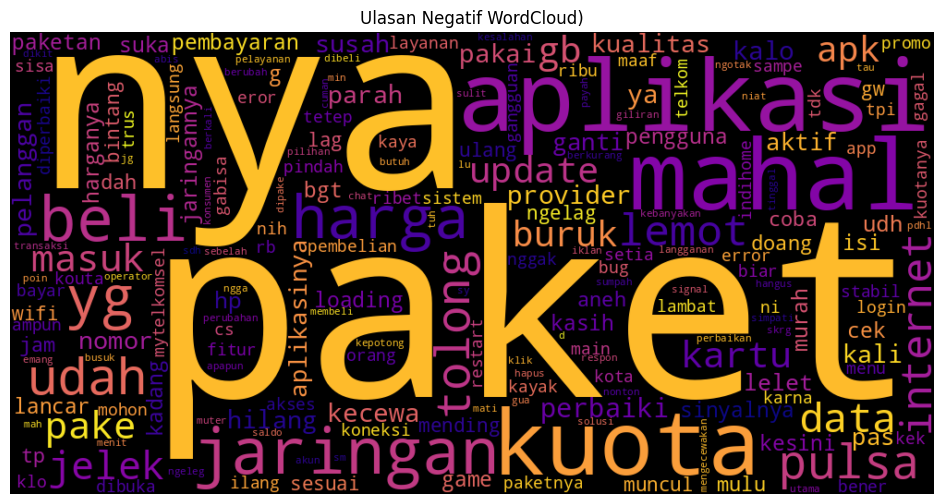

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Menggabungkan semua teks dari ulasan negatif menjadi satu string besar
negatif_reviews = data_clean[data_clean['Label'] == 'Negatif']
all_negative_text = ' '.join(negatif_reviews['text_Stopword'])

# Membuat dan menghasilkan WordCloud untuk ulasan negatif dengan latar belakang hitam
wordcloud_negatif = WordCloud(width=1000, height=500, background_color='black',
                              colormap='plasma', # Colormap yang cocok untuk latar belakang gelap
                              collocations=False).generate(all_negative_text)

# Menampilkan gambar WordCloud untuk ulasan negatif
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_negatif, interpolation='bilinear')
plt.axis("off") # Menghilangkan sumbu x dan y
plt.title('Ulasan Negatif WordCloud)')

# Menyimpan dan menampilkan gambar
plt.savefig('wordcloud_negatif_black_background.png')
plt.show()

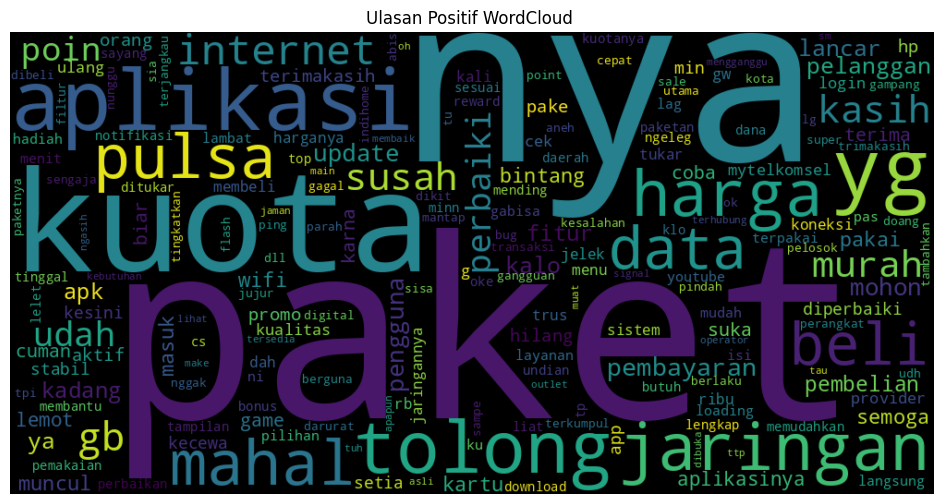

In [39]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Gabungkan semua teks dari ulasan positif menjadi satu string besar
positif_reviews = data_clean[data_clean['Label'] == 'Positif']
all_positive_text = ' '.join(positif_reviews['text_Stopword'])

# Membuat dan menghasilkan WordCloud untuk ulasan positif dengan latar belakang hitam
wordcloud_positif = WordCloud(width=1000, height=500, background_color='black',
                              colormap='viridis', # Colormap yang berbeda untuk kontras
                              collocations=False).generate(all_positive_text)

# Menampilkan gambar WordCloud untuk ulasan positif
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_positif, interpolation='bilinear')
plt.axis("off") # Menghilangkan sumbu x dan y
plt.title('Ulasan Positif WordCloud ')

# Menyimpan dan menampilkan gambar
plt.savefig('wordcloud_positif_black_background.png')
plt.show()

Testing

In [ ]:
from imblearn.over_sampling import SMOTE


smote = SMOTE(random_state=42) # menggunakan random_state agar hasil reproducible


X_train_resampled, y_train_resampled = smote.fit_resample(X_train_vectorized, y_train)

print("Shape data training sebelum SMOTE:", X_train_vectorized.shape)
print("Shape data training setelah SMOTE:", X_train_resampled.shape)

# Hitung jumlah sampel per kelas setelah SMOTE
from collections import Counter
print("Jumlah sampel per kelas setelah SMOTE:", Counter(y_train_resampled))

Shape data training sebelum SMOTE: (1483, 38816)
Shape data training setelah SMOTE: (2680, 38816)
Jumlah sampel per kelas setelah SMOTE: Counter({'Negatif': 1340, 'Positif': 1340})


In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Inisialisasi model Multinomial Naive Bayes baru
# Menggunakan hyperparameter default terlebih dahulu
nb_smote = MultinomialNB()

nb_smote.fit(X_train_resampled, y_train_resampled)

print("Model Naive Bayes dilatih dengan data training setelah SMOTE.")

# Melakukan prediksi
y_pred_smote = nb_smote.predict(X_test_vectorized) # Use the vectorized test data

# Menghitung dan menampilkan metrik evaluasi
print("\nEvaluasi Model Naive Bayes Setelah SMOTE (pada data test asli):")

# Akurasi
accuracy_smote = accuracy_score(y_test, y_pred_smote)
print(f"Accuracy: {accuracy_smote}")

# Confusion Matrix
cm_smote = confusion_matrix(y_test, y_pred_smote)
print("\nConfusion Matrix:")
print(cm_smote)

# Classification Report
# Ensure correct target_names
report_smote = classification_report(y_test, y_pred_smote, target_names=['Negatif', 'Positif'])
print("\nClassification Report:")
print(report_smote)

Model Naive Bayes dilatih dengan data training setelah SMOTE.

Evaluasi Model Naive Bayes Setelah SMOTE (pada data test asli):
Accuracy: 0.9245283018867925

Confusion Matrix:
[[343   0]
 [ 28   0]]

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.92      1.00      0.96       343
     Positif       0.00      0.00      0.00        28

    accuracy                           0.92       371
   macro avg       0.46      0.50      0.48       371
weighted avg       0.85      0.92      0.89       371



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import re
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# create stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# stemmed
def stemmed_wrapper(term):
    # Avoid stemming words that are important for sentiment like 'bagus'
    if term in ['bagus', 'baik', 'oke', 'mantap', 'cepat', 'mudah']: # Add more positive words if needed
        return term
    return stemmer.stem(term)

# Example of a clearly positive review
positive_example_text = "Aplikasi ini sangat bagus dan mudah digunakan, saya sangat suka!"

# Preprocessing teks baru 
# 1. Cleaning text (remove special characters and convert to lowercase)
new_text_clean = re.sub(r'[^a-zA-Z\s]', '', str(positive_example_text).lower())
# 2. Remove numbers
new_text_clean = re.sub(r'\d+', '', new_text_clean)
# 3. Stopword Removal
new_text_Stopword = ' '.join([word for word in new_text_clean.split() if word not in (stop)])
# 4. Tokenizing (split into words)
new_text_tokens = new_text_Stopword.split()
# 5. Stemming
new_text_stemindo = ' '.join([stemmed_wrapper(term) for term in new_text_tokens])


new_text_vectorized = vectorizer.transform([new_text_stemindo]) # menggunakan teks yang sudah di-stemmed dan ubah menjadi list

# Menggunakan model Naive Bayes yang dilatih setelah SMOTE (nb_smote)
prediction = nb_smote.predict(new_text_vectorized)

# Check the predicted label and set the sentiment_label accordingly
sentiment_label = prediction[0]

print("\nHasil Analisis Sentimen untuk Teks Baru (Contoh Positif): ", sentiment_label)




Hasil Analisis Sentimen untuk Teks Baru (Contoh Positif):  Negatif


In [47]:
import re
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Re-initialize stemmer and stopwords if they are not globally available in the current execution context
# (though in Colab they usually persist across cells)
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemmed_wrapper(term):
    if term in ['bagus', 'baik', 'oke', 'mantap', 'cepat', 'mudah']:
        return term
    return stemmer.stem(term)

# Ensure 'stop' and 'term_dict' are available, assuming they are defined in previous cells
# If not, you might need to re-run the previous preprocessing cells or redefine them here.

# Get new text input from the user
new_user_text = input("Masukkan teks baru untuk klasifikasi sentimen: ")

# 1. Cleaning text (remove special characters and convert to lowercase)
new_text_clean_user = re.sub(r'[^a-zA-Z\s]', '', str(new_user_text).lower())
# 2. Remove numbers
new_text_clean_user = re.sub(r'\d+', '', new_text_clean_user)

# 3. Stopword Removal
# Make sure 'stop' list is correctly defined from previous steps
new_text_stopword_user = ' '.join([word for word in new_text_clean_user.split() if word not in (stop)])

# 4. Tokenizing (split into words)
new_text_tokens_user = new_text_stopword_user.split()

# 5. Stemming
# Make sure 'term_dict' is correctly populated from previous steps
stemmed_tokens = []
for term in new_text_tokens_user:
    # Check if the term exists in term_dict, otherwise stem it directly
    if term in term_dict:
        stemmed_tokens.append(term_dict[term])
    else:
        stemmed_tokens.append(stemmed_wrapper(term))

new_text_stemindo_user = ' '.join(stemmed_tokens)

# Vectorize the preprocessed new text using the *same* vectorizer fitted on training data
# Ensure 'vectorizer' object is available from previous cells (CountVectorizer)
new_text_vectorized_user = vectorizer.transform([new_text_stemindo_user])

# Predict using the trained model (nb_smote)
# Ensure 'nb_smote' object is available from previous cells (MultinomialNB)
prediction_user = nb_smote.predict(new_text_vectorized_user)

sentiment_label_user = prediction_user[0]

print(f"\nHasil Analisis Sentimen untuk Teks Anda: {sentiment_label_user}")

Masukkan teks baru untuk klasifikasi sentimen: aplikasinya bagus

Hasil Analisis Sentimen untuk Teks Anda: Positif
